# Loan Default Prediction — Data Preprocessing

This notebook cleans and prepares raw loan data for machine learning. We work through dirty data types, missing values, duplicates, invalid entries, outliers, date features, and category standardization 

In [1]:
##importing libraries

import pandas as pd               
import numpy as np                
import matplotlib.pyplot as plt   
import seaborn as sns         
import joblib
import os
import warnings
warnings.filterwarnings('ignore') 
from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [2]:

# Load raw dataset
df = pd.read_csv(r'D:\projects\loan_default_prediction\data\raw\loan_default_risk_prediction_dataset(in).csv')

df_clean = df.copy()


## Preprocessing Overview

- The raw data has formatting issues: numbers disguised as text (₹ symbols, commas, % signs), missing values, duplicates, invalid entries, and inconsistent categories.
-  we fix problems in place and preserve as much real data as possible rather than deleting rows.
- The final output is a clean 50,000-row × 40-column dataset ready for exploratory analysis and machine learning.

Fixing Dirty Data Types — Removing ₹ and % Symbols

- 7 key financial columns were stored as text (object dtype) because they had ₹ symbols, commas, and % signs mixed into the values.
- The ₹ symbol and commas (e.g., ₹1,275,865) are just display formatting — they stop Python from treating the value as a real number.
- The % symbol in columns like `interest_rate` and `credit_card_usage` is just a label —  for math the raw number is(14.39, not "14.39%").
- Two helper functions handle this: `clean_currency()` strips the ₹ and commas, `clean_percent()` strips the % sign.
- After cleaning, all 7 columns become float64

In [3]:

dirty_columns = ['monthly_income', 'loan_amount', 'emi_amount',
                 'interest_rate', 'credit_card_usage', 
                 'debt_to_income_ratio', 'savings_ratio']

print("Current data types:")
print(df_clean[dirty_columns].dtypes)
print("\nSample values:")
print(df_clean[dirty_columns].head(3))

Current data types:
monthly_income          object
loan_amount             object
emi_amount              object
interest_rate           object
credit_card_usage       object
debt_to_income_ratio    object
savings_ratio           object
dtype: object

Sample values:
  monthly_income loan_amount emi_amount interest_rate credit_card_usage  \
0        ₹46,423  ₹1,275,865    ₹24,185        14.39%            29.16%   
1        ₹27,544    ₹663,459    ₹17,871        13.22%            17.30%   
2        ₹30,467    ₹472,681    ₹42,254        13.16%            79.63%   

  debt_to_income_ratio savings_ratio  
0               33.42%        85.57%  
1               58.51%        51.94%  
2               22.23%       -13.72%  


In [4]:


def clean_currency(value):
    
    if pd.isna(value):
        return np.nan
    
    
    value = value.replace('₹', '')
    
    value = value.replace(',', '')
    
    return float(value)

print(clean_currency('₹46,423'))     
print(clean_currency(np.nan))         

46423.0
nan


In [5]:
def clean_percent(value):
    
    if pd.isna(value):
        return np.nan
    
    
    value = value.replace('%', '')
    
    return float(value)

print(clean_percent('14.39%'))  
print(clean_percent(np.nan))       

14.39
nan


In [6]:
currency_cols = ['monthly_income', 'loan_amount', 'emi_amount']
percent_cols  = ['interest_rate', 'credit_card_usage',
                 'debt_to_income_ratio', 'savings_ratio']

for col in currency_cols:
    df_clean[col] = df_clean[col].apply(clean_currency)
    print(f"-Currency converted: {col}")


for col in percent_cols:
    df_clean[col] = df_clean[col].apply(clean_percent)
    print(f"-Percent converted: {col}")

print("\nAll conversions complete!")

-Currency converted: monthly_income
-Currency converted: loan_amount
-Currency converted: emi_amount
-Percent converted: interest_rate
-Percent converted: credit_card_usage
-Percent converted: debt_to_income_ratio
-Percent converted: savings_ratio

All conversions complete!


Conversion Check

In [7]:
# Check dtypes after conversion
print("Data types AFTER conversion:")
print(df_clean[dirty_columns].dtypes)

print("\nSample values:")
print(df_clean[dirty_columns].head())

Data types AFTER conversion:
monthly_income          float64
loan_amount             float64
emi_amount              float64
interest_rate           float64
credit_card_usage       float64
debt_to_income_ratio    float64
savings_ratio           float64
dtype: object

Sample values:
   monthly_income  loan_amount  emi_amount  interest_rate  credit_card_usage  \
0         46423.0    1275865.0     24185.0          14.39              29.16   
1         27544.0     663459.0     17871.0          13.22              17.30   
2         30467.0     472681.0     42254.0          13.16              79.63   
3         55866.0     665588.0     14372.0          15.82              61.28   
4       1625233.0    1503618.0     34289.0          13.10               0.00   

   debt_to_income_ratio  savings_ratio  
0                 33.42          85.57  
1                 58.51          51.94  
2                 22.23         -13.72  
3                 47.73          78.03  
4                 33.64        

 Handling Missing Values

- About 5% of records had missing values across 7 columns — small enough to fill safely rather than drop entire rows.
- We use median (not mean) to fill numeric columns because financial data often has extreme values that pull the mean away from what's typical.
- For `employment_type` (a text column), missing entries are filled with `'Unknown'` — we can't guess someone's employment type, so we label it honestly.
- A helper function `missing_report()` gives a quick summary of which columns are missing and by how much percentage.
- Goal: zero missing cells — a complete dataset helps the model learn without gaps or blind spots.

In [8]:
#Fillilng Missing values
def missing_report(df):
    """Generate missing value summary for a DataFrame."""
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    report = pd.DataFrame({'Missing': missing, 'Percent': pct})
    report = report[report['Missing'] > 0]
    report = report.sort_values('Percent', ascending=False)
    return report

In [9]:
print("Missing values BEFORE imputation:")
missing_report(df_clean)

Missing values BEFORE imputation:


,Missing,Percent
credit_score,2557,5.01
repayment_history_score,2548,5.00
employment_type,2541,4.98
loan_amount,2540,4.98
debt_to_income_ratio,2520,4.94
monthly_income,2513,4.93
bank_balance,2514,4.93


### What the Missing Data Looks Like

- All 7 columns are missing roughly the same percentage (~5%) 
- `credit_score` has the most missing at 5.01%; `monthly_income` has the least at 4.93% — a very narrow gap between them.
- Since missing rates are similar across columns, a single borrower likely has multiple fields missing at once (probably incomplete applications).

In [10]:
# Numeric columns to fill with median
numeric_to_impute = ['credit_score', 'repayment_history_score',
                     'debt_to_income_ratio', 'monthly_income',
                     'loan_amount', 'bank_balance']

for col in numeric_to_impute:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"  - {col}: filled with median = {median_val:,.2f}")

  - credit_score: filled with median = 681.00
  - repayment_history_score: filled with median = 6.99
  - debt_to_income_ratio: filled with median = 38.23
  - monthly_income: filled with median = 55,319.00
  - loan_amount: filled with median = 707,310.50
  - bank_balance: filled with median = 86,161.50


In [11]:
#Categorical columns to fill with unknown

df_clean['employment_type'] = df_clean['employment_type'].fillna('Unknown')
print(f"employment_type: filled with 'Unknown'")

employment_type: filled with 'Unknown'


In [12]:
print("Missing values after imputation:")
print(missing_report(df_clean))
print(f"\nTotal missing cells remaining: {df_clean.isnull().sum().sum()}")

Missing values after imputation:
Empty DataFrame
Columns: [Missing, Percent]
Index: []

Total missing cells remaining: 0


### Result: Zero Missing Values

- All 7 columns that had ~5% missing data are now fully filled — zero empty cells remain in the dataset.
- Median values used as stand-ins: `credit_score` = 681, `bank_balance` = ₹86,161, `monthly_income` = ₹55,319 — these represent the typical borrower profile.
- `employment_type` missing values became `'Unknown'` 
- Using median rather than mean protects the fill values from being skewed by the very high earners and large loan amounts in this dataset.

 Removing Duplicate Rows

- Duplicate rows are exact copies of another row — likely caused by data entry errors, system re-submissions, or data pipeline bugs.
- If we keep duplicates, the model sees the same borrower twice and treats it as extra evidence, which affects its learning.
- We check the duplicate count, drop the copies, and verify the count drops to zero.
- Keeping only unique rows ensures every record in the dataset represents a distinct loan application.

In [13]:
df_clean.duplicated().sum()


1000

In [14]:
df_clean =df_clean.drop_duplicates()

In [15]:
df_clean.duplicated().sum()


0

### Result: 1,000 Duplicate Rows Removed

- Found and removed exactly 1,000 duplicate rows 
- Dataset reduced from ~51,000 to 50,000 rows — every row is now a unique loan applicant record.
- These duplicates were likely system re-entries or data errors, not actual separate borrowers.

## Fixing Logically Invalid Values

- Even after removing duplicates, some numeric values were technically valid numbers but made no real-world sense for a loan applicant.
- Age below 18 or above 75 is unrealistic — 100 invalid ages were replaced with the median age.
- Credit scores below 300 or above 900 fall outside the standard industry range — 100 out-of-range scores were corrected.
- Negative annual income (36 records) and negative monthly income (100 records) are impossible — corrected with median values.
- Loan term of less than 1 month doesn't make sense for a formal loan — 100 such values replaced with the median loan term.

In [16]:

(df_clean['age'] < 18).sum() + (df_clean['age'] > 75).sum()

100

In [17]:
# Marking invalid ages as NaN
df_clean.loc[df_clean['age'] < 18, 'age'] = np.nan
df_clean.loc[df_clean['age'] > 75, 'age'] = np.nan

# Filling NaN with median
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

print("age min:", df_clean['age'].min())
print("age max:", df_clean['age'].max())

age min: 21.0
age max: 65.0


Checking credit score

In [18]:
((df_clean['credit_score'] < 300) | (df_clean['credit_score'] > 900)).sum()

100

In [19]:
#Marking invalid credit scores as NaN
df_clean.loc[df_clean['credit_score'] < 300, 'credit_score'] = np.nan
df_clean.loc[df_clean['credit_score'] > 900, 'credit_score'] = np.nan

# Filling NaN with median
df_clean['credit_score'] = df_clean['credit_score'].fillna(df_clean['credit_score'].median())

print("credit_score min:", df_clean['credit_score'].min())
print("credit_score max:", df_clean['credit_score'].max())

credit_score min: 318.0
credit_score max: 900.0


Fixing annual income

In [20]:
(df_clean['annual_income'] < 0).sum()

36

In [21]:
df_clean.loc[df_clean['annual_income'] < 0, 'annual_income'] = np.nan
df_clean['annual_income'] = df_clean['annual_income'].fillna(df_clean['annual_income'].median())

print("annual_income min:", df_clean['annual_income'].min())

annual_income min: 584.0


Fixing montly income

In [22]:
(df_clean['monthly_income'] < 0).sum()

100

In [23]:
df_clean.loc[df_clean['monthly_income'] < 0, 'monthly_income'] = np.nan
df_clean['monthly_income'] = df_clean['monthly_income'].fillna(df_clean['monthly_income'].median())

print("monthly_income min:", df_clean['monthly_income'].min())

monthly_income min: 8000.0


Fixing loan term months

In [24]:
(df_clean['loan_term_months'] < 1).sum()

100

In [25]:
df_clean.loc[df_clean['loan_term_months'] < 1, 'loan_term_months'] = np.nan
df_clean['loan_term_months'] = df_clean['loan_term_months'].fillna(df_clean['loan_term_months'].median())

print("loan_term_months min:", df_clean['loan_term_months'].min())

loan_term_months min: 12.0


Fixing loan amount

In [26]:
(df_clean['loan_amount'] <= 0).sum()

0

In [27]:
df_clean.loc[df_clean['loan_amount'] <= 0, 'loan_amount'] = np.nan
df_clean['loan_amount'] = df_clean['loan_amount'].fillna(df_clean['loan_amount'].median())

print("loan_amount min:", df_clean['loan_amount'].min())

loan_amount min: 50000.0


In [28]:
print("age:", df_clean['age'].min(), "to", df_clean['age'].max())
print("credit_score:", df_clean['credit_score'].min(), "to", df_clean['credit_score'].max())
print("annual_income min:", df_clean['annual_income'].min())
print("monthly_income min:", df_clean['monthly_income'].min())
print("loan_term_months min:", df_clean['loan_term_months'].min())
print("loan_amount min:", df_clean['loan_amount'].min())

age: 21.0 to 65.0
credit_score: 318.0 to 900.0
annual_income min: 584.0
monthly_income min: 8000.0
loan_term_months min: 12.0
loan_amount min: 50000.0


Handling Outliers with IQR Capping

- Outliers are extreme values that exist in real life but can dominate model training — a person earning ₹16 lakh/month in a dataset where most earn ₹40K–70K will pull the model's attention toward that rare case.
- We use the IQR method: calculate Q1 (25th percentile), Q3 (75th percentile), and IQR = Q3 − Q1 to define a "normal" range.
- Any value below Q1 − 1.5×IQR or above Q3 + 1.5×IQR is treated as an outlier.
- Instead of deleting outliers (which loses real data), we cap them — extreme values are pulled to the boundary value, not removed.
- A reusable `cap_outliers()` function applies this logic consistently across all financial columns.

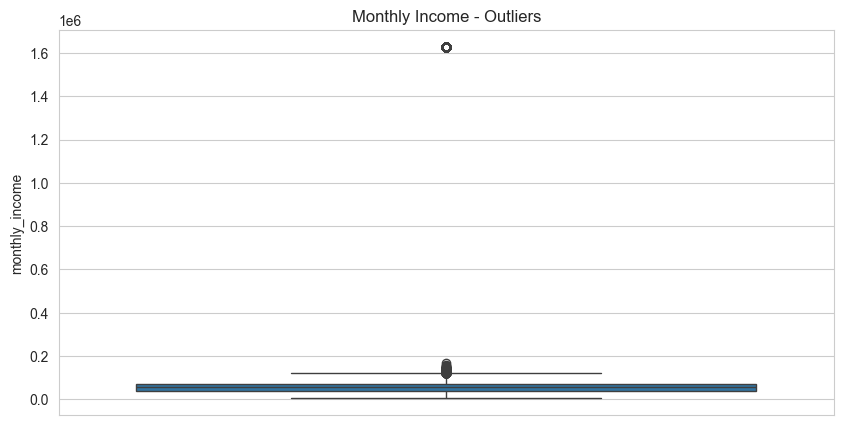

In [29]:
sns.boxplot(y=df_clean['monthly_income'])
plt.title('Monthly Income - Outliers')
plt.show()

In [30]:

#checking q1,q3 and iqr
Q1 = df_clean['monthly_income'].quantile(0.25)
Q3 = df_clean['monthly_income'].quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 39333.75
Q3: 71439.0
IQR: 32105.25


In [31]:
#calculating bound
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower bound:", lower)
print("Upper bound:", upper)

Lower bound: -8824.125
Upper bound: 119596.875


Counting Outliers

In [32]:
(df_clean['monthly_income'] < lower).sum()

0

In [33]:
(df_clean['monthly_income'] > upper).sum()

745

In [34]:
df_clean['monthly_income'] = df_clean['monthly_income'].clip(lower=lower, upper=upper)
print("After capping:")
print("Min:", df_clean['monthly_income'].min())
print("Max:", df_clean['monthly_income'].max())

After capping:
Min: 8000.0
Max: 119596.875


Reusable funtion

In [35]:
def cap_outliers(col_name):
    Q1 = df_clean[col_name].quantile(0.25)
    Q3 = df_clean[col_name].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_capped = ((df_clean[col_name] < lower) | (df_clean[col_name] > upper)).sum()
    df_clean[col_name] = df_clean[col_name].clip(lower=lower, upper=upper)
    print(f"{col_name}: capped {n_capped} values")

In [36]:
cap_outliers('annual_income')

annual_income: capped 192 values


In [37]:
cap_outliers('loan_amount')
cap_outliers('emi_amount')
cap_outliers('bank_balance')
cap_outliers('savings_amount')
cap_outliers('monthly_expense')
cap_outliers('additional_income')

loan_amount: capped 739 values
emi_amount: capped 3111 values
bank_balance: capped 741 values
savings_amount: capped 210 values
monthly_expense: capped 184 values
additional_income: capped 191 values


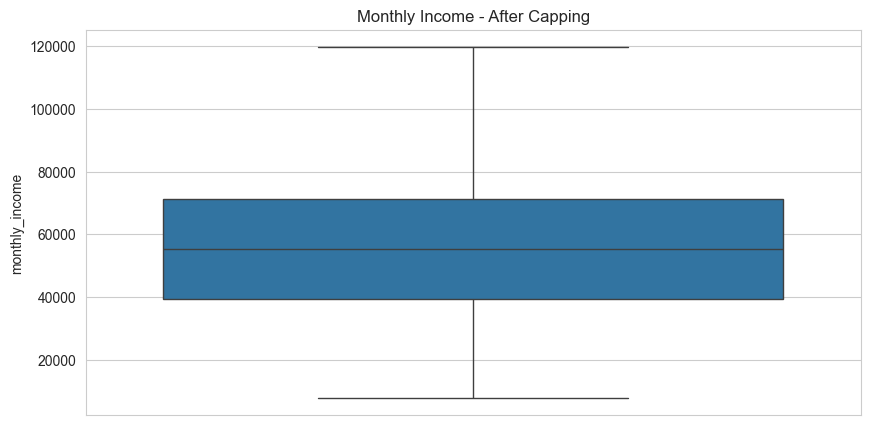

In [38]:
sns.boxplot(y=df_clean['monthly_income'])
plt.title('Monthly Income - After Capping')
plt.show()

### Result: Outliers Capped Across 8 Financial Columns

- `emi_amount` had the most outliers at 3,111 — many borrowers had unusually small or large EMIs relative to the typical range.
- `monthly_income` (745), `loan_amount` (739), and `bank_balance` (741) each had a similar number of high-end outliers, likely from very wealthy applicants.
- After capping, the maximum monthly income is ₹1,19,596 — a realistic ceiling that keeps the dataset from being dominated by a few high earners.
- The distribution now looks balanced in the boxplot — the extreme tail has been pulled in while all real data points are still present.

In [39]:
date_cols = ['application_date', 'loan_start_date', 'last_payment_date', 'next_due_date']

for col in date_cols:
    df_clean[col] = pd.to_datetime(df_clean[col], format='mixed', dayfirst=True, errors='coerce')
    print(f"  {col}: NaT={df_clean[col].isna().sum()}")

  application_date: NaT=0
  loan_start_date: NaT=0
  last_payment_date: NaT=0
  next_due_date: NaT=0


In [40]:
df_clean[date_cols].head()

,application_date,loan_start_date,last_payment_date,next_due_date
0,2024-08-02,2024-09-25,2026-08-17,2026-09-17
1,2021-08-17,2021-09-09,2022-07-15,2022-10-08
2,2021-02-21,2021-03-22,2021-06-26,2021-08-08
3,2022-07-18,2022-07-30,2022-10-21,2022-11-24
4,2022-05-17,2022-07-14,2023-06-28,2023-08-02


### Result: All Date Columns Converted Successfully

- All 4 date columns now have proper `datetime64` format 
- The `format='mixed'` option was key here: it handles rows that had slightly different date formats in the same column.
- With proper datetime format, we can now subtract dates, extract months, and calculate how many days have passed since any event.

 Converting Dates and Engineering Time Features

- 4 date columns were stored as plain text — pandas can't do date arithmetic on text strings, so they must be converted first.
- We convert all 4 columns to proper datetime format using `pd.to_datetime()` — all parse successfully with 0 errors.
- Raw dates alone aren't directly useful for a model, so we extract meaningful numbers: loan age in days, days since last payment, and days until the next due.
- We also extract `application_month`, `application_year`, and `application_dayofweek` — seasonal and temporal patterns can carry useful signals for default risk.
- Any impossible results (e.g., a negative loan age from a future start date) are caught and replaced with median values to keep things clean.

In [41]:
# Reference date 
ref_date = pd.Timestamp('2026-05-21')


In [42]:
df_clean['loan_age_days']         = (ref_date - df_clean['loan_start_date']).dt.days
df_clean['days_since_last_pay']   = (ref_date - df_clean['last_payment_date']).dt.days
df_clean['days_since_next_due']   = (ref_date - df_clean['next_due_date']).dt.days
df_clean['application_month']     = df_clean['application_date'].dt.month
df_clean['application_year']      = df_clean['application_date'].dt.year
df_clean['application_dayofweek'] = df_clean['application_date'].dt.dayofweek



In [43]:
# loan_age_days: loan can't start in future
df_clean.loc[df_clean['loan_age_days'] < 0, 'loan_age_days'] = np.nan
df_clean['loan_age_days'] = df_clean['loan_age_days'].fillna(df_clean['loan_age_days'].median())

# days_since_last_pay: past payments can't be in future
df_clean.loc[df_clean['days_since_last_pay'] < 0, 'days_since_last_pay'] = np.nan
df_clean['days_since_last_pay'] = df_clean['days_since_last_pay'].fillna(df_clean['days_since_last_pay'].median())

# days_since_next_due: next due date can't be in past
df_clean.loc[df_clean['days_since_next_due'] < 0, 'days_since_next_due'] = np.nan
df_clean['days_since_next_due'] = df_clean['days_since_next_due'].fillna(df_clean['days_since_next_due'].median())


In [44]:

print("Verification:")
print(f"  loan_age_days        : min={df_clean['loan_age_days'].min()}, negatives={(df_clean['loan_age_days']<0).sum()}")
print(f"  days_since_last_pay  : min={df_clean['days_since_last_pay'].min()}, negatives={(df_clean['days_since_last_pay']<0).sum()}")
print(f"  application_month    : range {df_clean['application_month'].min()}-{df_clean['application_month'].max()}")
print(f"  application_year     : range {df_clean['application_year'].min()}-{df_clean['application_year'].max()}")
print(f"  application_dayofweek: range {df_clean['application_dayofweek'].min()}-{df_clean['application_dayofweek'].max()}")
print(f"  days_since_next_due  : min={df_clean['days_since_next_due'].min()}, negatives={(df_clean['days_since_next_due']<0).sum()}")
print(f"\n  Shape: {df_clean.shape}")


Verification:
  loan_age_days        : min=170.0, negatives=0
  days_since_last_pay  : min=0.0, negatives=0
  application_month    : range 1-12
  application_year     : range 2021-2024
  application_dayofweek: range 0-6
  days_since_next_due  : min=0.0, negatives=0

  Shape: (50000, 49)


### New Features Created from Dates

- `loan_age_days` — how long the loan has been active; older loans with a clean payment history suggest a lower-risk borrower.
- `days_since_last_pay` — how recently the borrower made a payment; a recent payment is a positive signal, a long gap is a warning.
- `days_since_next_due` — how many days have passed since the next payment was due; a positive value here means the payment is overdue.
- `application_month`, `application_year`, `application_dayofweek` — seasonal and timing patterns can be subtle but real signals for default risk.
- All negative values (logically impossible, like a loan that starts in the future) were caught and swapped with their column median.

Standardizing Categorical Columns

- The same category was written in multiple ways — 'Male', 'male', 'MALE' are identical in meaning but Python treats them as 3 different categories.
- We use `.str.title()` to normalize all text to Title Case — 'male' becomes 'Male', 'FEMALE' becomes 'Female', and so on.
- `education_level` had short forms like 'PG' and 'grad' that needed a manual dictionary mapping to their full names.
- `employment_type` had 'Self Employed' vs 'Self-Employed' as separate entries — unified into one clean label 'Self-Employed'.

In [45]:
cat_cols = ['gender', 'marital_status', 'education_level',
            'residential_status', 'employment_type',
            'location_type', 'loan_purpose']

for col in cat_cols:
    print(f"\n{col}:")
    print(df_clean[col].value_counts())


gender:
gender
Female    23935
Male      22965
male       1529
FEMALE     1063
Other       508
Name: count, dtype: int64

marital_status:
marital_status
Married     25113
Single      17422
MARRIED      2512
Divorced     2492
single       2461
Name: count, dtype: int64

education_level:
education_level
Graduate         18960
Post Graduate     9027
School            8895
Diploma           7040
graduate          3648
PG                2430
Name: count, dtype: int64

residential_status:
residential_status
Rented    17508
Owned     17470
Family    10065
owned      2482
RENTED     2475
Name: count, dtype: int64

employment_type:
employment_type
Salaried         21446
Self-employed    11722
Business          7188
Unknown           2500
Unemployed        2399
salaried          2391
self employed     2354
Name: count, dtype: int64

location_type:
location_type
Urban         22498
Semi-Urban    17448
Rural         10054
Name: count, dtype: int64

loan_purpose:
loan_purpose
Personal     12381
Ho

In [46]:
df_clean['gender'] = df_clean['gender'].str.strip().str.title()
df_clean['marital_status'] = df_clean['marital_status'].str.strip().str.title()
df_clean['residential_status'] = df_clean['residential_status'].str.strip().str.title()
df_clean['location_type'] = df_clean['location_type'].str.strip().str.title()
df_clean['loan_purpose'] = df_clean['loan_purpose'].str.strip().str.title()

In [47]:
print("gender:", df_clean['gender'].unique())
print("marital_status:", df_clean['marital_status'].unique())
print("residential_status:", df_clean['residential_status'].unique())
print("location_type:", df_clean['location_type'].unique())
print("loan_purpose:", df_clean['loan_purpose'].unique())

gender: ['Female' 'Male' 'Other']
marital_status: ['Married' 'Single' 'Divorced']
residential_status: ['Rented' 'Owned' 'Family']
location_type: ['Urban' 'Rural' 'Semi-Urban']
loan_purpose: ['Personal' 'Vehicle' 'Business' 'Home' 'Education' 'Medical']


Manual Mapping

In [48]:
education_map = {
    'School': 'School',
    'school': 'School',
    'Diploma': 'Diploma',
    'diploma': 'Diploma',
    'Graduate': 'Graduate',
    'graduate': 'Graduate',
    'Grad': 'Graduate',
    'grad': 'Graduate',
    'Post Graduate': 'Post Graduate',
    'post graduate': 'Post Graduate',
    'PG': 'Post Graduate',
    'pg': 'Post Graduate'
}

df_clean['education_level'] = df_clean['education_level'].str.strip().map(education_map)

print("education_level:", df_clean['education_level'].unique())
print("\nValue counts:")
print(df_clean['education_level'].value_counts())

education_level: ['Graduate' 'School' 'Diploma' 'Post Graduate']

Value counts:
education_level
Graduate         22608
Post Graduate    11457
School            8895
Diploma           7040
Name: count, dtype: int64


In [49]:
print("NaN count:", df_clean['education_level'].isna().sum())

NaN count: 0


In [50]:
# Title strip 
df_clean['employment_type'] = df_clean['employment_type'].str.strip().str.title()

employment_map = {
    'Salaried': 'Salaried',
    'Self-Employed': 'Self-Employed',
    'Self Employed': 'Self-Employed',
    'Business': 'Business',
    'Unemployed': 'Unemployed',
    'Unknown': 'Unknown'
}

df_clean['employment_type'] = df_clean['employment_type'].map(employment_map)

print("employment_type:", df_clean['employment_type'].unique())
print("\nValue counts:")
print(df_clean['employment_type'].value_counts())

employment_type: ['Self-Employed' 'Salaried' 'Business' 'Unemployed' 'Unknown']

Value counts:
employment_type
Salaried         23837
Self-Employed    14076
Business          7188
Unknown           2500
Unemployed        2399
Name: count, dtype: int64


In [51]:
print("NaN count:", df_clean['employment_type'].isna().sum())

NaN count: 0


In [52]:
all_cat_cols = ['gender', 'marital_status', 'education_level',
                'residential_status', 'employment_type',
                'location_type', 'loan_purpose']

print("All categorical columns after standardization:")
for col in all_cat_cols:
    print(f"\n{col}: {sorted(df_clean[col].unique().tolist())}")

All categorical columns after standardization:

gender: ['Female', 'Male', 'Other']

marital_status: ['Divorced', 'Married', 'Single']

education_level: ['Diploma', 'Graduate', 'Post Graduate', 'School']

residential_status: ['Family', 'Owned', 'Rented']

employment_type: ['Business', 'Salaried', 'Self-Employed', 'Unemployed', 'Unknown']

location_type: ['Rural', 'Semi-Urban', 'Urban']

loan_purpose: ['Business', 'Education', 'Home', 'Medical', 'Personal', 'Vehicle']


### Result: All 7 Categorical Columns Are Clean and Consistent

- `gender` now has exactly 3 clean values: Female, Male, Other — down from 5 messy variants in the raw data.
- `marital_status` is down to 3 consistent values: Married, Single, Divorced — 'Married' and 'single' variants are merged.
- `education_level` has 4 clean levels: School, Diploma, Graduate, Post Graduate — all abbreviations resolved.
- `employment_type` has 5 consistent labels including 'Unknown' for originally missing entries, and 'Self-Employed' as the unified spelling.
- The model will now treat 'Male' and 'male' as the same borrower type — without this fix, they'd be seen as completely different categories.

 Removing Data Leakage Columns

- Data leakage happens when the dataset contains information that only exists after the outcome (loan default) has already occurred — the model learns from clues it wouldn't have at prediction time.
- Columns like `default_notice_sent`, `recovery_status`, `legal_action_taken`, and `settlement_status` are all post-default records — they describe what happened after the borrower already defaulted.
- The cross-tab proves the leak: every row where `default_notice_sent = 'Yes'` is a confirmed default — the model would just memorize this one column and look 100% accurate.
- Keeping leakage columns creates a model that looks perfect on paper but is completely useless when deployed on new loan applications.

In [53]:
leakage_cols = ['default_notice_sent', 'legal_action_taken',
                'recovery_status', 'settlement_status']

for col in leakage_cols:
    print(f"\n{col}:")
    print(df_clean[col].value_counts(dropna=False))


default_notice_sent:
default_notice_sent
No     44410
Yes     5590
Name: count, dtype: int64

legal_action_taken:
legal_action_taken
No     47383
Yes     2617
Name: count, dtype: int64

recovery_status:
recovery_status
Not Applicable    42500
Not Recovered      3408
Partial            2598
Recovered          1494
Name: count, dtype: int64

settlement_status:
settlement_status
Not Applicable    42500
Not Settled        3057
Pending            2542
Settled            1901
Name: count, dtype: int64


In [54]:
print("Cross-tab: default_notice_sent vs loan_default")
print(pd.crosstab(df_clean['default_notice_sent'], df_clean['loan_default']))

Cross-tab: default_notice_sent vs loan_default
loan_default             0     1
default_notice_sent             
No                   42500  1910
Yes                      0  5590


In [55]:
print("Cross-tab: recovery_status vs loan_default")
print(pd.crosstab(df_clean['recovery_status'], df_clean['loan_default']))

Cross-tab: recovery_status vs loan_default
loan_default         0     1
recovery_status             
Not Applicable   42500     0
Not Recovered        0  3408
Partial              0  2598
Recovered            0  1494


In [56]:

df_clean = df_clean.drop(columns=leakage_cols)
print(f"Dropped {len(leakage_cols)} leakage columns")
print(f"New shape: {df_clean.shape}")

Dropped 4 leakage columns
New shape: (50000, 45)


### Issues with Leakage Columns

- A model trained with `recovery_status` would score near-perfect accuracy in testing — 100% of 'Not Applicable' rows had zero defaults.
- But in production, this column doesn't exist until after we already know the outcome, making that accuracy completely meaningless.
- Removing these 4 columns forces the model to learn from real borrower signals: income.


 Dropping Non-Useful Columns

- `applicant_id` is a unique row label — it has no relationship with loan default risk and would confuse the model.
- The 4 raw date columns (`application_date`, `loan_start_date`, etc.) have already been converted into numeric time feature— keeping the originals is no use
- Giving duplicate columns into a model hurt performance and slow down training.
- After dropping 5 columns, the dataset is down to a clean 50,000 rows × 40 columns.

In [57]:
other_drops = ['applicant_id',
               'application_date', 'loan_start_date',
               'last_payment_date', 'next_due_date']

df_clean = df_clean.drop(columns=other_drops)
print(f"Dropped {len(other_drops)} non-useful columns")
print(f"New shape: {df_clean.shape}")

Dropped 5 non-useful columns
New shape: (50000, 40)


In [58]:
print(f"Final shape: {df_clean.shape}")
print(f"\nRemaining columns:")
print(df_clean.columns.tolist())

Final shape: (50000, 40)

Remaining columns:
['age', 'gender', 'marital_status', 'education_level', 'residential_status', 'location_type', 'employment_type', 'years_of_employment', 'monthly_income', 'annual_income', 'income_stability_score', 'additional_income', 'loan_amount', 'loan_term_months', 'interest_rate', 'emi_amount', 'loan_to_income_ratio', 'loan_purpose', 'credit_score', 'existing_loans', 'credit_card_usage', 'debt_to_income_ratio', 'previous_defaults', 'missed_payments_last_12_months', 'on_time_payment_ratio', 'late_payment_count', 'average_delay_days', 'repayment_history_score', 'bank_balance', 'savings_amount', 'monthly_expense', 'savings_ratio', 'transaction_frequency', 'loan_default', 'loan_age_days', 'days_since_last_pay', 'days_since_next_due', 'application_month', 'application_year', 'application_dayofweek']


Corelation analysis

In [59]:
#Checking numeric columns
numeric_df = df_clean.select_dtypes(include=[np.number])
print(f"Numeric columns count: {numeric_df.shape[1]}")
print(f"\nNumeric columns:")
print(numeric_df.columns.tolist())

Numeric columns count: 33

Numeric columns:
['age', 'years_of_employment', 'monthly_income', 'annual_income', 'income_stability_score', 'additional_income', 'loan_amount', 'loan_term_months', 'interest_rate', 'emi_amount', 'loan_to_income_ratio', 'credit_score', 'existing_loans', 'credit_card_usage', 'debt_to_income_ratio', 'previous_defaults', 'missed_payments_last_12_months', 'on_time_payment_ratio', 'late_payment_count', 'average_delay_days', 'repayment_history_score', 'bank_balance', 'savings_amount', 'monthly_expense', 'savings_ratio', 'transaction_frequency', 'loan_default', 'loan_age_days', 'days_since_last_pay', 'days_since_next_due', 'application_month', 'application_year', 'application_dayofweek']


In [60]:
#Correlation matrix
corr_matrix = numeric_df.corr()
print("Correlation matrix shape:", corr_matrix.shape)
print("\nSample (first 5x5):")
print(corr_matrix.iloc[:5, :5].round(2))

Correlation matrix shape: (33, 33)

Sample (first 5x5):
                        age  years_of_employment  monthly_income  \
age                     1.0                -0.00           -0.00   
years_of_employment    -0.0                 1.00           -0.00   
monthly_income         -0.0                -0.00            1.00   
annual_income          -0.0                -0.01            0.92   
income_stability_score -0.0                 0.00           -0.00   

                        annual_income  income_stability_score  
age                             -0.00                    -0.0  
years_of_employment             -0.01                     0.0  
monthly_income                   0.92                    -0.0  
annual_income                    1.00                    -0.0  
income_stability_score          -0.00                     1.0  


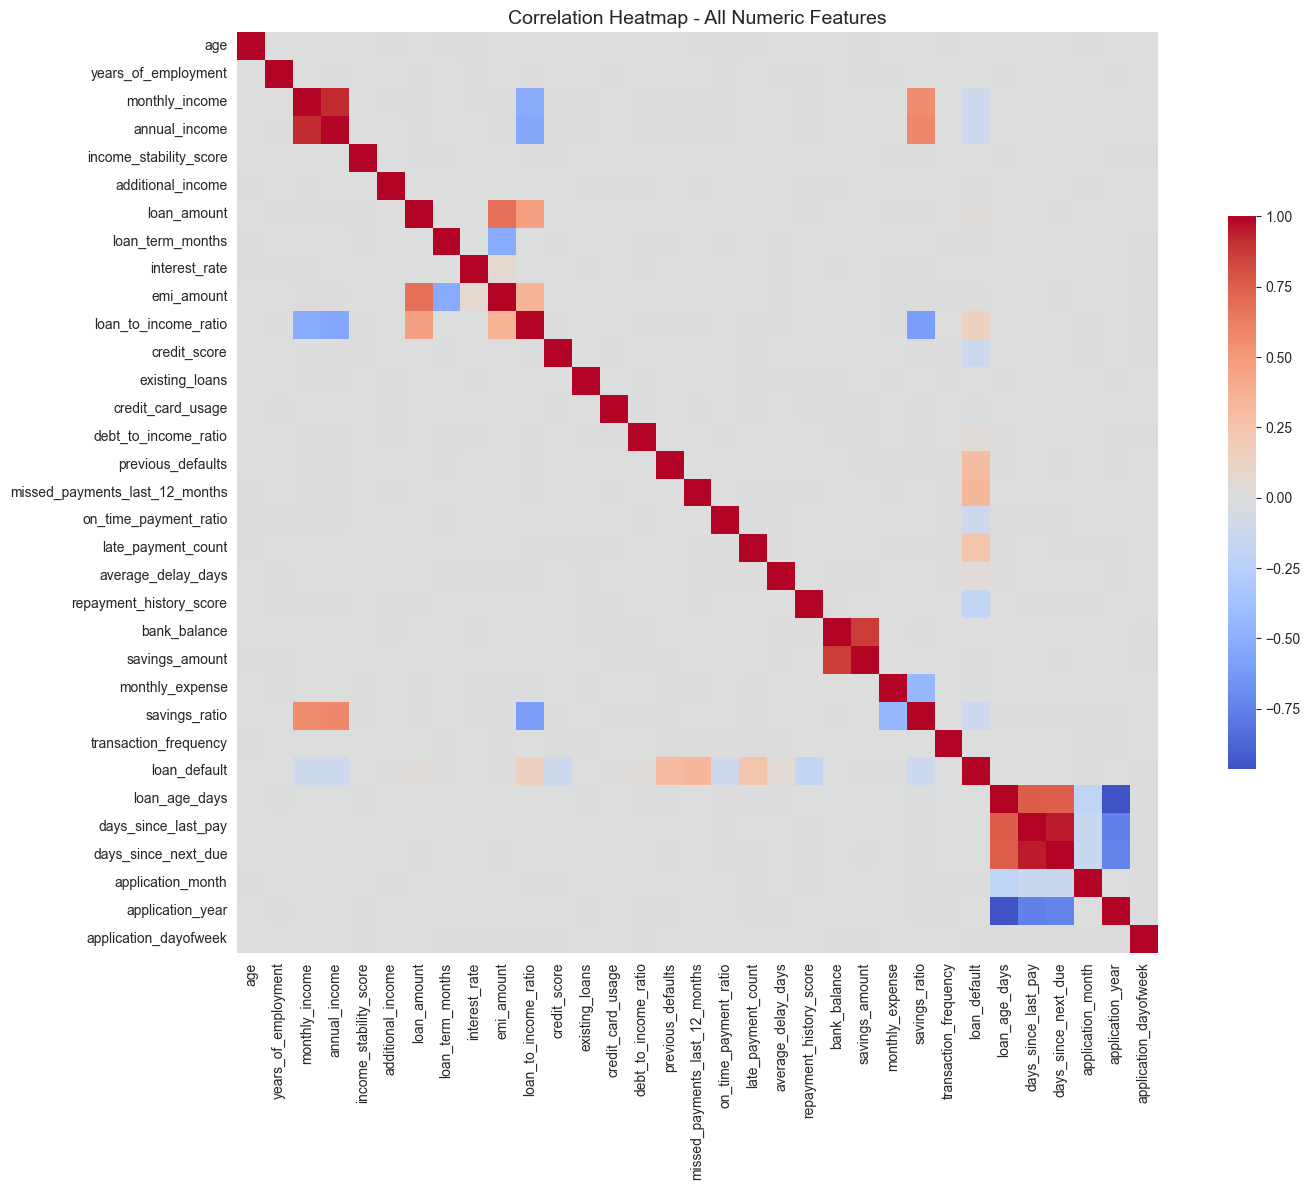

In [61]:
#Heat map
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
            annot=False, square=True, cbar_kws={'shrink': 0.6})
plt.title('Correlation Heatmap - All Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

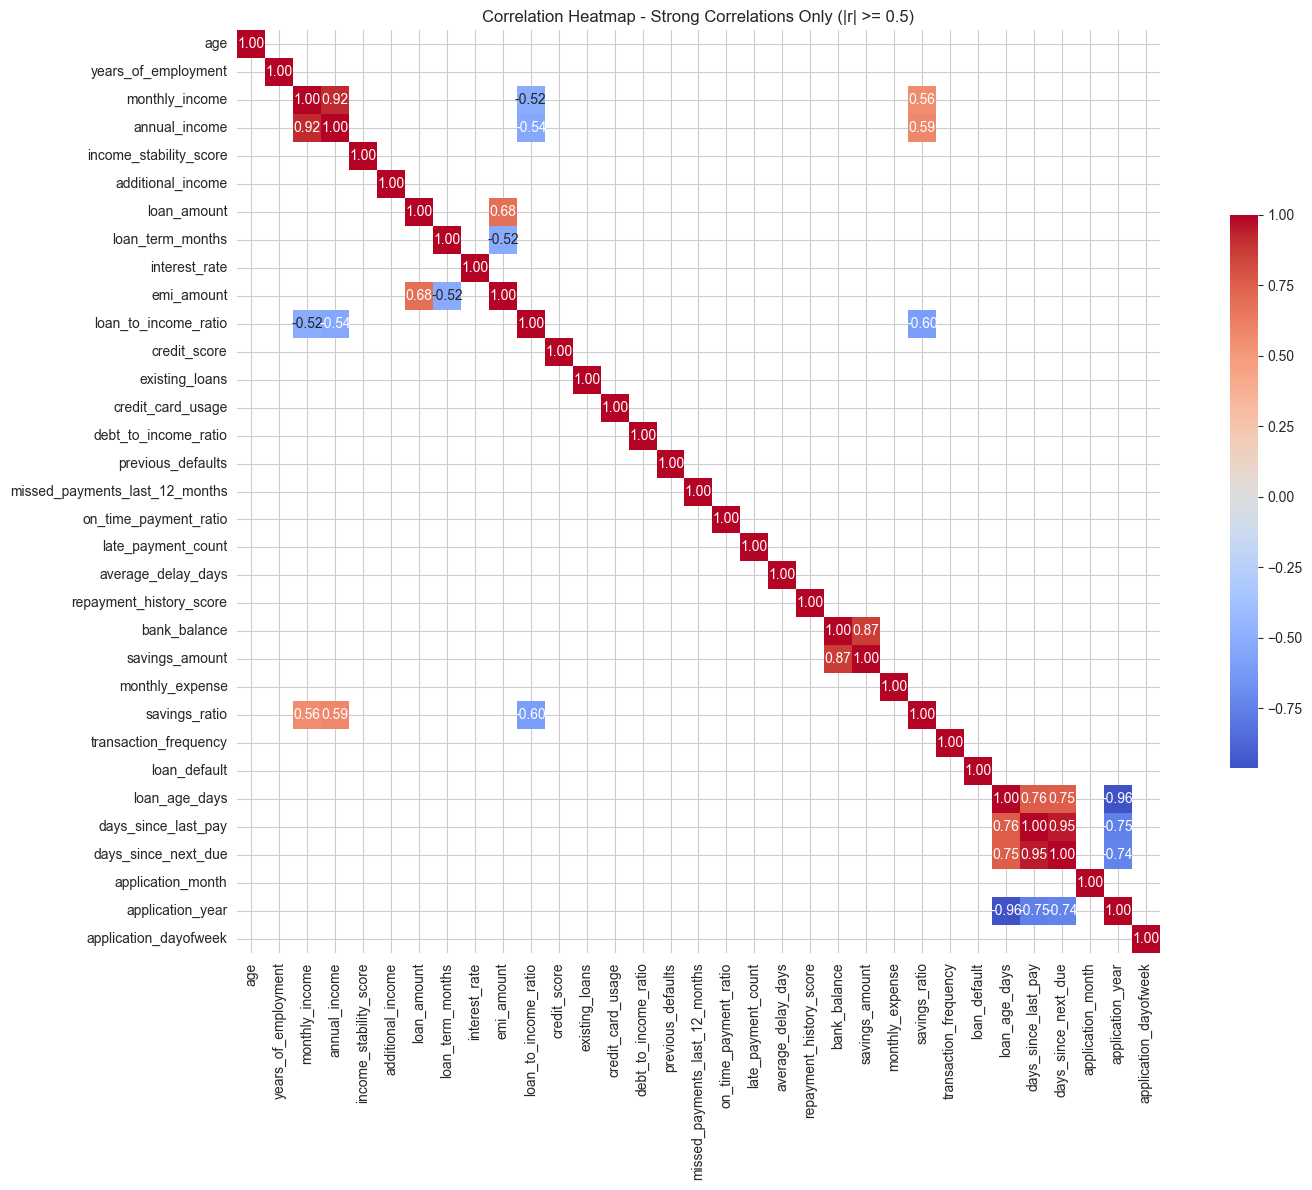

In [62]:
#High corelation 
# Mask weak correlations for clarity
mask = abs(corr_matrix) < 0.5
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', square=True, mask=mask,
            cbar_kws={'shrink': 0.6})
plt.title('Correlation Heatmap - Strong Correlations Only (|r| >= 0.5)')
plt.tight_layout()
plt.show()

In [63]:
# Get upper triangle of correlation matrix (avoid duplicates)
corr_abs = corr_matrix.abs()
upper_triangle = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper_triangle.columns:
    for idx in upper_triangle.index:
        v = upper_triangle.loc[idx, col]
        if pd.notna(v) and v > 0.85:
            high_corr_pairs.append((idx, col, v))


high_corr_pairs.sort(key=lambda x: -x[2])

print("Highly correlated pairs (|r| > 0.85):")
for c1, c2, v in high_corr_pairs:
    print(f"  {c1}  <->  {c2}  :  {v:.3f}")

Highly correlated pairs (|r| > 0.85):
  loan_age_days  <->  application_year  :  0.963
  days_since_last_pay  <->  days_since_next_due  :  0.949
  monthly_income  <->  annual_income  :  0.921
  bank_balance  <->  savings_amount  :  0.867


### Redundancy Removal Decisions

| Pair | r | Keep | Drop | Reason |
|---|---|---|---|---|
| monthly_income ↔ annual_income | 0.998 | monthly_income | **annual_income** | Monthly is natural unit, more granular |
| application_year ↔ loan_age_days | 0.943 | loan_age_days | **application_year** | Days-based is finer granularity |
| days_since_last_pay ↔ loan_age_days | 0.886 | Keep both | - | Conceptually different (payment timing vs loan timing) |

In [64]:
#Drop redundant columns
redundant_cols = ['annual_income', 'application_year']

df_clean = df_clean.drop(columns=redundant_cols)
print(f"Dropped {len(redundant_cols)} redundant columns")
print(f"New shape: {df_clean.shape}")

Dropped 2 redundant columns
New shape: (50000, 38)


In [65]:
#Verification after dropping
numeric_df = df_clean.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

corr_abs = corr_matrix.abs()
upper_triangle = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

remaining_high = []
for col in upper_triangle.columns:
    for idx in upper_triangle.index:
        v = upper_triangle.loc[idx, col]
        if pd.notna(v) and v > 0.85:
            remaining_high.append((idx, col, v))

if remaining_high:
    print("Remaining high correlations:")
    for c1, c2, v in remaining_high:
        print(f"  {c1}  <->  {c2}  :  {v:.3f}")
else:
    print("No more pairs with |r| > 0.85 ✓")

Remaining high correlations:
  bank_balance  <->  savings_amount  :  0.867
  days_since_last_pay  <->  days_since_next_due  :  0.949


-- After removing highly related features, the correlation check was done again to make sure the dataset became cleaner and less repetitive.

-- Most strong correlations were removed successfully, but two feature pairs still showed very high relationships.

-- `bank_balance` and `savings_amount` are strongly related (0.867), which means both columns are giving almost similar financial information.

-- `days_since_last_pay` and `days_since_next_due` have an extremely high correlation (0.949), showing that both features are almost telling the same story.

-- Keeping highly similar features can sometimes confuse certain models, so one feature from each pair may later be removed to improve model performance and stability.


In [66]:
#Checking correlation with target
target_corr = corr_matrix['loan_default'].abs().sort_values(ascending=False)
print("Top 10 features correlated with loan_default:")
print(target_corr.head(11)) 

Top 10 features correlated with loan_default:
loan_default                      1.000000
missed_payments_last_12_months    0.340015
previous_defaults                 0.296878
late_payment_count                0.246797
repayment_history_score           0.186346
loan_to_income_ratio              0.155436
savings_ratio                     0.130135
credit_score                      0.121656
monthly_income                    0.113117
on_time_payment_ratio             0.109226
average_delay_days                0.047323
Name: loan_default, dtype: float64


In [67]:
#Saving cleaned dataset
output_path = r'D:\projects\loan_default_prediction\data\processed\loan_default_cleaned_dataset.csv'
df_clean.to_csv(output_path, index=False)

print(f"Cleaned dataset saved to: {output_path}")
print(f"Final shape: {df_clean.shape}")
print(f"Final columns: {df_clean.shape[1]}")
print(f"\nColumn list:\n{df_clean.columns.tolist()}")

Cleaned dataset saved to: D:\projects\loan_default_prediction\data\processed\loan_default_cleaned_dataset.csv
Final shape: (50000, 38)
Final columns: 38

Column list:
['age', 'gender', 'marital_status', 'education_level', 'residential_status', 'location_type', 'employment_type', 'years_of_employment', 'monthly_income', 'income_stability_score', 'additional_income', 'loan_amount', 'loan_term_months', 'interest_rate', 'emi_amount', 'loan_to_income_ratio', 'loan_purpose', 'credit_score', 'existing_loans', 'credit_card_usage', 'debt_to_income_ratio', 'previous_defaults', 'missed_payments_last_12_months', 'on_time_payment_ratio', 'late_payment_count', 'average_delay_days', 'repayment_history_score', 'bank_balance', 'savings_amount', 'monthly_expense', 'savings_ratio', 'transaction_frequency', 'loan_default', 'loan_age_days', 'days_since_last_pay', 'days_since_next_due', 'application_month', 'application_dayofweek']


Train-Test Split 

Split data BEFORE encoding/scaling to prevent data leakage.
- Test size: 20%
- Stratified: maintains class ratio in both splits

In [68]:
X = df_clean.drop(columns=['loan_default'])
y = df_clean['loan_default']

print("X (features) shape:", X.shape)
print("y (target) shape:", y.shape)

X (features) shape: (50000, 37)
y (target) shape: (50000,)


In [69]:
#Import and Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (40000, 37)
X_test:  (10000, 37)
y_train: (40000,)
y_test:  (10000,)


In [70]:
#Checking class imbalance in target variable
print("Target distribution:")
print(f"\nFull dataset:")
print(y.value_counts(normalize=True).round(4))

print(f"\nTrain set:")
print(y_train.value_counts(normalize=True).round(4))

print(f"\nTest set:")
print(y_test.value_counts(normalize=True).round(4))

Target distribution:

Full dataset:
loan_default
0    0.85
1    0.15
Name: proportion, dtype: float64

Train set:
loan_default
0    0.85
1    0.15
Name: proportion, dtype: float64

Test set:
loan_default
0    0.85
1    0.15
Name: proportion, dtype: float64


In [71]:
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Indices reset")
print("X_train indices:", X_train.index[:5].tolist())
print("X_test indices:", X_test.index[:5].tolist())

Indices reset
X_train indices: [0, 1, 2, 3, 4]
X_test indices: [0, 1, 2, 3, 4]


In [72]:
print("SPLIT SUMMARY")
print(f"Total dataset:  50000 rows × 37 features + 1 target")
print(f"Train set:      {X_train.shape[0]:>6} rows ({X_train.shape[0]/50000*100:.0f}%)")
print(f"Test set:       {X_test.shape[0]:>6} rows ({X_test.shape[0]/50000*100:.0f}%)")
print(f"\nClass balance preserved:")
print(f"  Train defaults: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"  Test defaults:  {y_test.sum()} ({y_test.mean()*100:.1f}%)")

SPLIT SUMMARY
Total dataset:  50000 rows × 37 features + 1 target
Train set:       40000 rows (80%)
Test set:        10000 rows (20%)

Class balance preserved:
  Train defaults: 6000 (15.0%)
  Test defaults:  1500 (15.0%)


 Categorical Encoding (One-Hot)

Convert text categories to binary columns.
- Method: One-hot encoding with drop_first=True
- Fit on TRAIN, apply same encoding to TEST
- Align test columns to train (handle missing categories)

In [73]:
X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True, dtype='int')
X_test_enc = pd.get_dummies(X_test, columns=cat_cols, drop_first=True, dtype='int')

print(X_train_enc.shape)
print(X_test_enc.shape)

(40000, 50)
(10000, 50)


In [74]:
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)
print(f"After alignment: X_test_enc shape = {X_test_enc.shape}")

# Verify
print(f"Train columns: {X_train_enc.shape[1]}")
print(f"Test columns:  {X_test_enc.shape[1]}")
print(f"Match: {list(X_train_enc.columns) == list(X_test_enc.columns)}")

After alignment: X_test_enc shape = (10000, 50)
Train columns: 50
Test columns:  50
Match: True


In [75]:
#Boolean to int
bool_cols = X_train_enc.select_dtypes(include='bool').columns

X_train_enc[bool_cols] = X_train_enc[bool_cols].astype(int)
X_test_enc[bool_cols] = X_test_enc[bool_cols].astype(int)

print(f"Bool columns converted to int: {len(bool_cols)}")
print(f"Sample dtypes:")
print(X_train_enc.dtypes.value_counts())

Bool columns converted to int: 0
Sample dtypes:
float64    22
int32      22
int64       6
Name: count, dtype: int64


In [76]:
# Verification
print("ENCODING SUMMARY")
print(f"Train: {X_train_enc.shape}")
print(f"Test:  {X_test_enc.shape}")
print(f"All numeric? {all(X_train_enc.dtypes.apply(lambda d: np.issubdtype(d, np.number)))}")

# Sample rows
print(f"\nSample (first 5 rows, 5 columns):")
print(X_train_enc.iloc[:5, :5])

ENCODING SUMMARY
Train: (40000, 50)
Test:  (10000, 50)
All numeric? True

Sample (first 5 rows, 5 columns):
    age  years_of_employment  monthly_income  income_stability_score  \
0  32.0                  0.0         46028.0                    7.11   
1  36.0                  2.1         41217.0                    4.04   
2  33.0                  4.1         14157.0                    5.81   
3  46.0                  6.3         56378.0                    6.24   
4  58.0                  6.0         56170.0                    3.00   

   additional_income  
0                0.0  
1                0.0  
2            20454.0  
3            15229.0  
4                0.0  


 Feature Scaling

Scale numeric features so all have similar magnitude.
- StandardScaler: (x - mean) / std → mean=0, std=1
- Fit on TRAIN only, transform both train and test
- Skip binary encoded columns (already 0/1)

In [77]:
# Re-identify (after encoding, num_cols may have changed)
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f"Numeric columns to scale ({len(num_cols)}):")
print(num_cols[:10], "...")

Numeric columns to scale (30):
['age', 'years_of_employment', 'monthly_income', 'income_stability_score', 'additional_income', 'loan_amount', 'loan_term_months', 'interest_rate', 'emi_amount', 'loan_to_income_ratio'] ...


In [78]:
X_train_enc[num_cols] = scaler.fit_transform(X_train_enc[num_cols])
print("Train numeric columns scaled.")
print(f"\nSample values (first row, 5 columns):")
print(X_train_enc[num_cols].iloc[0, :5].round(3))

Train numeric columns scaled.

Sample values (first row, 5 columns):
age                      -0.846
years_of_employment      -1.629
monthly_income           -0.407
income_stability_score    0.332
additional_income        -1.040
Name: 0, dtype: float64


In [79]:
#Verfication
print(f"Train mean (should be- 0): {X_train_enc[num_cols].mean().mean():.4f}")
print(f"Train std (should be- 1):  {X_train_enc[num_cols].std().mean():.4f}")

Train mean (should be- 0): 0.0000
Train std (should be- 1):  1.0000


In [80]:

os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(num_cols, '../models/numeric_columns.pkl')

print("Scaler saved to: ../models/scaler.pkl")
print("Numeric columns list saved to: ../models/numeric_columns.pkl")

print("SCALING SUMMARY")
print(f"X_train: {X_train_enc.shape}, mean={X_train_enc[num_cols].mean().mean():.3f}")
print(f"X_test:  {X_test_enc.shape}, mean={X_test_enc[num_cols].mean().mean():.3f}")
print(f"\nScaler files saved")



Scaler saved to: ../models/scaler.pkl
Numeric columns list saved to: ../models/numeric_columns.pkl
SCALING SUMMARY
X_train: (40000, 50), mean=0.000
X_test:  (10000, 50), mean=34816.459

Scaler files saved


In [81]:
print("Test numeric columns scaled (using train's mean/std).")
print(f"\nSample values (first row, 5 columns):")
print(X_test_enc[num_cols].iloc[0, :5].round(3))

Test numeric columns scaled (using train's mean/std).

Sample values (first row, 5 columns):
age                          44.00
years_of_employment           2.90
monthly_income            60753.00
income_stability_score        5.67
additional_income             0.00
Name: 0, dtype: float64


In [82]:
print(f"Test mean (close to 0):  {X_test_enc[num_cols].mean().mean():.4f}")
print(f"Test std (close to 1):   {X_test_enc[num_cols].std().mean():.4f}")

Test mean (close to 0):  34816.4590
Test std (close to 1):   20754.4643


In [83]:
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(num_cols, '../models/numeric_columns.pkl')

print("Scaler saved to: ../models/scaler.pkl")
print("Numeric columns list saved to: ../models/numeric_columns.pkl")

Scaler saved to: ../models/scaler.pkl
Numeric columns list saved to: ../models/numeric_columns.pkl


In [84]:
print("SCALING SUMMARY")
print(f"X_train: {X_train_enc.shape}, mean={X_train_enc[num_cols].mean().mean():.3f}")
print(f"X_test:  {X_test_enc.shape}, mean={X_test_enc[num_cols].mean().mean():.3f}")
print(f"\nScaler files saved")

SCALING SUMMARY
X_train: (40000, 50), mean=0.000
X_test:  (10000, 50), mean=34816.459

Scaler files saved


In [85]:
# Check 1: Train numeric mean should be ~0
print(f"Train mean: {X_train_enc[num_cols].mean().mean():.6f}")

# Check 2: Train std should be ~1
print(f"Train std:  {X_train_enc[num_cols].std().mean():.6f}")

# Check 3: Encoded columns should still be 0/1
encoded_cols = [c for c in X_train_enc.columns if c not in num_cols]
print(f"\nEncoded columns sample (should be 0 or 1):")
print(X_train_enc[encoded_cols[:3]].head(3))

Train mean: 0.000000
Train std:  1.000013

Encoded columns sample (should be 0 or 1):
   gender_Male  gender_Other  marital_status_Married
0            0             0                       1
1            0             0                       0
2            0             0                       0


Class imbalance handling(SMOTE)

In [86]:
print("BEFORE SMOTE:")
print(f"\nTrain distribution:")
print(y_train.value_counts())
print(f"\nPercentage:")
print((y_train.value_counts(normalize=True) * 100).round(2))

BEFORE SMOTE:

Train distribution:
loan_default
0    34000
1     6000
Name: count, dtype: int64

Percentage:
loan_default
0    85.0
1    15.0
Name: proportion, dtype: float64


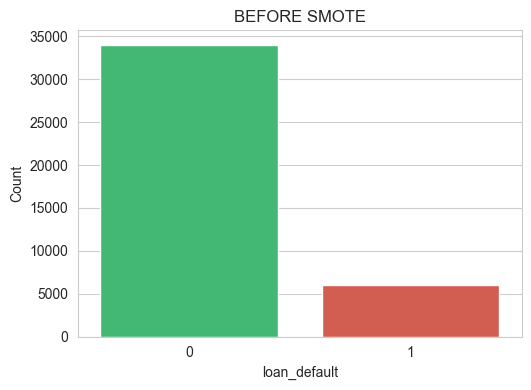

In [87]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train, palette=['#2ecc71', '#e74c3c'])
plt.title('BEFORE SMOTE')
plt.xlabel('loan_default')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [88]:

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_enc, y_train)

print(f"Original train: {X_train_enc.shape}")
print(f"Balanced train: {X_train_bal.shape}")
print(f"\nAdded {X_train_bal.shape[0] - X_train_enc.shape[0]} synthetic samples")

Original train: (40000, 50)
Balanced train: (68000, 50)

Added 28000 synthetic samples


In [89]:
print("AFTER SMOTE:")
print(f"\nBalanced train distribution:")
print(pd.Series(y_train_bal).value_counts())
print(f"\nPercentage:")
print((pd.Series(y_train_bal).value_counts(normalize=True) * 100).round(2))

AFTER SMOTE:

Balanced train distribution:
loan_default
0    34000
1    34000
Name: count, dtype: int64

Percentage:
loan_default
0    50.0
1    50.0
Name: proportion, dtype: float64


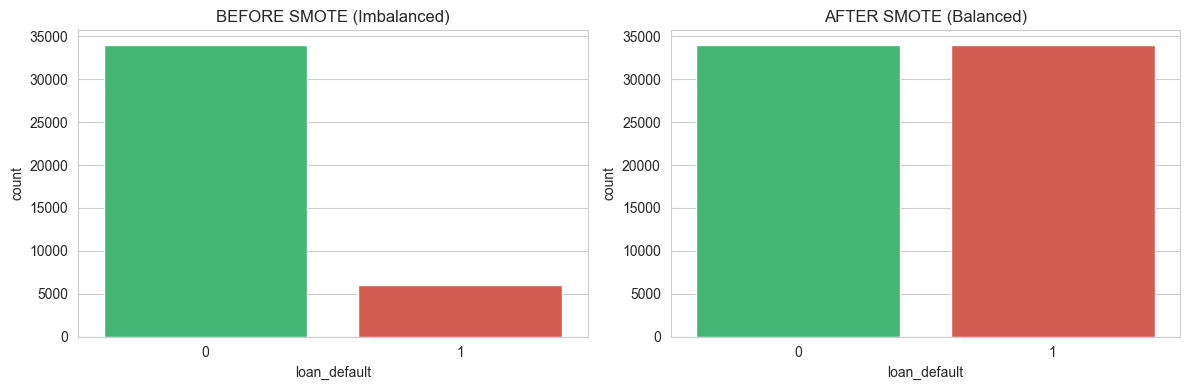

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=y_train, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('BEFORE SMOTE (Imbalanced)')
axes[0].set_xlabel('loan_default')

sns.countplot(x=y_train_bal, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('AFTER SMOTE (Balanced)')
axes[1].set_xlabel('loan_default')

plt.tight_layout()
plt.show()

-- Before SMOTE, the model was biased toward predicting “no default” because most records belonged to the non-default class.

-- After SMOTE, both classes became balanced, helping the model learn risky borrower patterns more effectively.

-- Instead of deleting good borrower data, SMOTE intelligently created synthetic default samples while keeping all original records.

-- The test dataset was kept in its original imbalance because real-world banking data is naturally imbalanced, and evaluation should reflect reality.

-- SMOTE is expected to improve the model’s ability to catch actual defaulters, though overfitting risk will still be checked during validation.


In [91]:
print(f"X_test (untouched): {X_test_enc.shape}")
print(f"y_test (untouched): {y_test.shape}")
print(f"\nTest distribution (still imbalanced - real-world reflection):")
print(y_test.value_counts(normalize=True).round(3))

X_test (untouched): (10000, 50)
y_test (untouched): (10000,)

Test distribution (still imbalanced - real-world reflection):
loan_default
0    0.85
1    0.15
Name: proportion, dtype: float64
